In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

BASE_PATH = "/content/drive/MyDrive/ds_harindranath"

os.makedirs(f"{BASE_PATH}/csv_files", exist_ok=True)
os.makedirs(f"{BASE_PATH}/outputs", exist_ok=True)


In [ ]:
import os

base_dir = "/content/ds_harindranath"

folders = [
    base_dir,
    f"{base_dir}/csv_files",
    f"{base_dir}/outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folder created at:", base_dir)


Project folder created at: /content/ds_harindranath


In [ ]:
import pandas as pd

sentiment_df= pd.read_csv("/content/ds_harindranath/csv_files/fear_greed_index.csv")

In [ ]:
trades_df = pd.read_csv("/content/ds_harindranath/csv_files/historical_data.csv")

In [ ]:
trades_df.info()
trades_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
trades_df = trades_df[trades_df['Size USD'] > 0]

numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee'
]

(trades_df[numeric_cols] == 0).sum()


,0
Execution Price,0
Size Tokens,0
Size USD,0
Start Position,4085
Closed PnL,106773
Fee,9605


In [ ]:
trades_df['Timestamp IST'] = pd.to_datetime(
    trades_df['Timestamp IST'],
    dayfirst=True
)

trades_df['date'] = trades_df['Timestamp IST'].dt.normalize()


In [ ]:
def simplify_sentiment(x):
    if x in ['Fear', 'Extreme Fear']:
        return 'Fear'
    elif x in ['Greed', 'Extreme Greed']:
        return 'Greed'
    else:
        return 'Neutral'

sentiment_df['market_sentiment'] = sentiment_df['classification'].apply(simplify_sentiment)

In [ ]:
sentiment_df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   date              2644 non-null   object
 1   market_sentiment  2644 non-null   object
dtypes: object(2)
memory usage: 41.4+ KB


In [ ]:
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])

In [ ]:
trades_df['date'].dtype
sentiment_df['date'].dtype



dtype('<M8[ns]')

In [ ]:
sentiment_df['market_sentiment'].value_counts()


,count
market_sentiment,
Fear,1289
Greed,959
Neutral,396


In [ ]:
sentiment_df = sentiment_df[['date', 'market_sentiment']]


In [ ]:
merged_df = trades_df.merge(
    sentiment_df,
    on='date',
    how='inner'
)


In [ ]:
merged_df['market_sentiment'].value_counts()


,count
market_sentiment,
Greed,90263
Fear,83226
Neutral,37686


In [ ]:
profit_summary = (
    merged_df
    .groupby('market_sentiment')['Closed PnL']
    .agg(
        trades='count',
        avg_pnl='mean',
        median_pnl='median',
        std_pnl='std'
    )
)

profit_summary


,trades,avg_pnl,median_pnl,std_pnl
market_sentiment,,,,
Fear,83226,49.218582,0.0,990.940717
Greed,90263,53.901384,0.0,977.136918
Neutral,37686,34.307718,0.0,517.122220


**Profitability vs Market Sentiment**

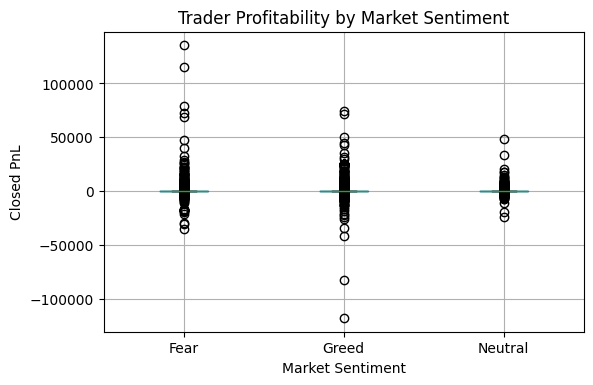

In [ ]:
import matplotlib.pyplot as plt

merged_df.boxplot(
    column='Closed PnL',
    by='market_sentiment',
    figsize=(6, 4)
)

plt.title("Trader Profitability by Market Sentiment")
plt.suptitle("")   # removes default pandas subtitle
plt.ylabel("Closed PnL")
plt.xlabel("Market Sentiment")

plt.savefig("/content/ds_harindranath/outputs/pnl_by_sentiment.png")
plt.show()


The boxplot shows that while median profitability remains close to zero across all sentiment regimes, both Fear and Greed periods exhibit wider PnL distributions compared to Neutral periods. This indicates higher volatility and the presence of extreme outcomes during emotionally driven market conditions.


**Trade Size (Risk Proxy) vs Market Sentiment**

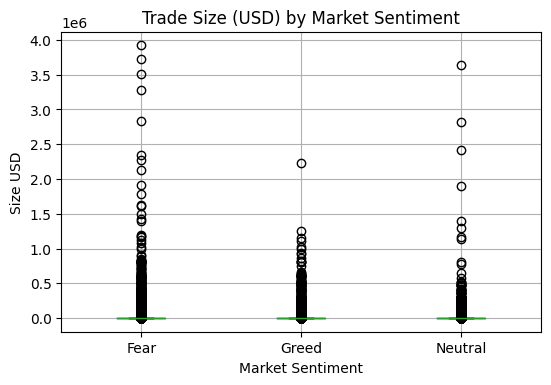

In [ ]:
import matplotlib.pyplot as plt

merged_df.boxplot(
    column='Size USD',
    by='market_sentiment',
    figsize=(6, 4)
)

plt.title("Trade Size (USD) by Market Sentiment")
plt.suptitle("")
plt.ylabel("Size USD")
plt.xlabel("Market Sentiment")

plt.savefig("/content/ds_harindranath/outputs/size_usd_by_sentiment.png")
plt.show()


Trade size was used as a proxy for risk exposure. The boxplot indicates that traders generally commit larger position sizes during Greed periods, reflecting increased risk appetite. Fear periods also show elevated trade sizes but with greater variability, suggesting less consistent risk-taking compared to Greed. Neutral markets are characterized by smaller and more stable trade sizes.

**Risk Concentration via Trade Size Quantiles**

In [ ]:
risk_quantiles = (
    merged_df
    .groupby('market_sentiment')['Size USD']
    .quantile([0.5, 0.75, 0.9])
    .unstack()
)

risk_quantiles


,0.50,0.75,0.90
market_sentiment,,,
Fear,749.475,2479.4075,10230.830
Greed,552.550,2000.1850,7877.694
Neutral,547.655,1994.2050,6940.985


Risk Concentration (Quantile Analysis):
Quantile analysis reveals that median trade sizes remain relatively stable across sentiment regimes, with Neutral markets showing slightly higher typical trade sizes.
However, the upper tail of the distribution differs substantially: Fear periods exhibit the largest extreme trade sizes at the 90th percentile, indicating concentrated and potentially panic-driven risk exposure.
Greed-driven trading shows elevated but comparatively more controlled risk levels, while Neutral periods demonstrate lower extreme risk despite moderate typical trade sizes.

**Directional Behavior (Buy vs Sell) by Market Sentiment**

In [ ]:
direction_dist = (
    merged_df
    .groupby(['market_sentiment', 'Side'])
    .size()
    .unstack(fill_value=0)
)

direction_dist


Side,BUY,SELL
market_sentiment,,
Fear,41205,42021
Greed,42516,47747
Neutral,18969,18717


In [ ]:
direction_ratio = direction_dist.div(direction_dist.sum(axis=1), axis=0)
direction_ratio


Side,BUY,SELL
market_sentiment,,
Fear,0.495098,0.504902
Greed,0.471024,0.528976
Neutral,0.503343,0.496657


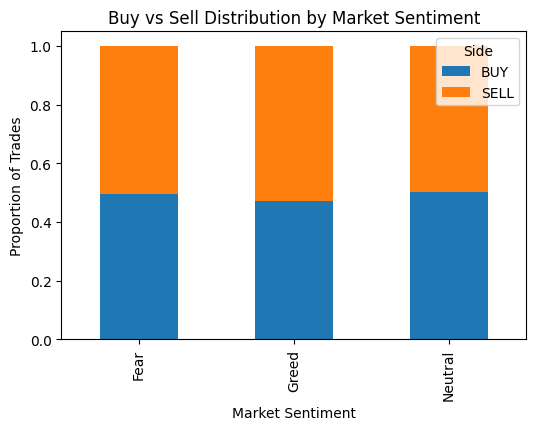

In [ ]:
import matplotlib.pyplot as plt

direction_ratio.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 4)
)

plt.title("Buy vs Sell Distribution by Market Sentiment")
plt.ylabel("Proportion of Trades")
plt.xlabel("Market Sentiment")

plt.legend(title="Side")
plt.savefig("/content/ds_harindranath/outputs/buy_sell_by_sentiment.png")
plt.show()


The Buy/Sell distribution varies across sentiment regimes. Fear periods show a slight bias toward Buy trades, suggesting contrarian or dip-buying behavior.
In contrast, Greed periods exhibit a mild Sell bias, indicating profit-taking or position unwinding during optimistic market conditions.
Neutral markets display a nearly balanced Buy/Sell distribution, reflecting stable and routine trading behavior.

In [ ]:
readme_content = """
# Trader Behavior vs Market Sentiment Analysis

## Overview
This project analyzes how trader behavior varies across different market sentiment regimes—Fear, Greed, and Neutral—by combining Bitcoin market sentiment data with historical trade-level data.

## Objectives
- Analyze profitability across sentiment regimes
- Study risk exposure using trade size as a proxy
- Examine Buy vs Sell behavior under Fear and Greed

## Project Structure
ds_harindranath/
├── notebook_1.ipynb
├── notebook_2.ipynb
├── csv_files/
├── outputs/
├── ds_report.pdf
└── README.md


---

## Methodology
1. Validated datasets for null values and datatype consistency
2. Standardized timestamps and aligned both datasets at daily granularity
3. Merged trade-level data with daily market sentiment
4. Performed exploratory data analysis across four dimensions:
   - Profitability
   - Trade size (risk proxy)
   - Risk concentration
   - Directional behavior (Buy vs Sell)

---

## Key Insights
- Median profitability is near zero across all sentiment regimes, indicating a large proportion of breakeven trades
- Average profitability and trading activity increase during Greed periods
- Fear markets exhibit the highest extreme risk concentration, indicating panic-driven behavior
- Traders tend to buy more during Fear and sell more during Greed, suggesting contrarian and profit-taking behavior
- Neutral markets show stable, balanced, and lower-risk trading behavior

---

## Tools & Libraries
- Python
- Pandas
- Matplotlib
- Google Colab

---

## Notes
- All analysis was performed in Google Colab
- All notebooks are shared as view-only links
- Outputs and intermediate files are organized according to the required directory structure

"""

with open("/content/ds_harindranath/README.md", "w") as f:
    f.write(readme_content)


In [ ]:
!ls /content/drive/MyDrive/ds_harindranath



csv_files  outputs


In [41]:
!ls /content/drive/MyDrive/ds_harindranath



csv_files  ds_report.pdf  Notebook_1.ipynb  outputs  README.md
